<a id='start' a>

[Цели и задачи проекта. Знакомство с данными.](#start)

---
1. [Предобработка данных](#p) 
    -   [1.1 Датасет с гипотезами](#hyp) 
        -    [Результат обработки](#hypo)  
        
    -   [1.2 Датасет с посетителями](#vis)
        -    [Результат обработки ](#visit) 
        
    -   [1.1 Датасет с покупками](#buy) 
        -    [Результат обработки ](#buyers) 
             
2. [2 Приоритизация гипотез.](#prior)

3. [3 A/B-тест](#test)
    -    [3.1  График кумулятивной выручки по группам](#gr1)
    -    [3.2 График среднего чека по группам.](#check)
    -    [3.3 График относительного изменения кумулятиного среднего чека группы B к группе A.](#check2)
    -    [3.4 Кумулятивная конверсия по группам A/B теста](#graph4)
    -    [3.5  График относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A](#graph5)
    -    [3.6 Точечный график количества заказов по пользователям](#point)
    -    [Точечный график стоимости заказов по пользователям.](#point2)

 
4. [Формулировка, проверка и интерпретация статистических гипотез.](#4)
    -  [Выбор статистического критерия](#crit)
    -  [4.1 Проверка гипотезы о различиях в среднем количестве заказов на пользователя в двух группах (критерий Манна-Уитни)](#4)
    -  [4.2 Сравнение среднего чека между группами по необработанным данным (критерий Манна-Уитни)](#5)
    -  [4.3 Сравнение среднего чека между группами по очищенным данным (критерий Манна-Уитни)](#clean) 
  

6. [Выводы и рекомендации](#last)

### «Оптимизация маркетинговых стратегий: приоритизация гипотез и анализ A/B-теста для роста выручки интернет-магазина»

**Контекст:**

    В условиях высокой конкуренции на рынке электронной коммерции наш интернет-магазин, во главе с отделом маркетинга  сформировал список гипотез, которые должны улучшить пользовательский опыт  и потенциально повысить ключевые бизнес-показатели .

**Цель проекта:**

-  Приоритезировать гипотезы с помощью фреймворков **ICE и RICE**, чтобы определить, какие из них наиболее перспективны для тестирования.

- Провести **A/B-тест** выбранной гипотезы и проанализировать его **результаты**.

- Принять решение на основе данных: масштабировать успешное изменение, доработать гипотезу или остановить тест.

**Данные**

В проекте используются три датасета:

**hypothesis.csv** — список гипотез с оценками охвата, влияния, уверенности и затрат.

**orders.csv** — данные о заказах (выручка, группы A/B-теста).

**visitors.csv** — количество пользователей в группах теста по дням.

**Ход исследования:**

- Проверю данные трёх таблиц на аномалии, пропуски и корректность. 
- Для гипотез применю ICE и RICE, сравню результаты и выявлю топ-идеи. 
- В A/B-тесте проанализирую кумулятивную выручку, средний чек и конверсию, построив динамические графики. 
- Изучу распределение заказов и выручки. 
- Проверю статистическую значимость различий между группами по «сырым» и очищенным данным с помощью подходящих статистических критериев.
- На основе p-value и размера эффекта приму решение о продолжении или остановке теста.
- Подведу общий итог с рекомендациями для маркетингового отдела.

In [1]:
# Необходимые библиотеки
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from IPython.display import display

## Подробное описание данных
**Файл с гипотезами hypothesis.csv**

- Hypothesis — краткое описание гипотезы;
- Reach — охват пользователей по 10-балльной шкале;
- Impact — влияние на пользователей по 10-балльной шкале;
- Confidence — уверенность в гипотезе по 10-балльной шкале;
- Efforts — затраты ресурсов на проверку гипотезы по 10-балльной шкале. Чем больше значение Efforts, тем дороже проверка гипотезы.


**Файл с заказами orders.csv**
- transactionId — идентификатор заказа;
- visitorId — идентификатор пользователя, совершившего заказ;
- date — дата, когда был совершён заказ;
- revenue — выручка заказа;
- group — группа A/B-теста, в которую попал заказ.

**Файл с посетителями visitors.csv**
- date — дата;
- group — группа A/B-теста;
- visitors — количество пользователей в указанную дату в указанной группе A/B-теста

<a id='#p' a>

## 1. Предобработка данных.

In [2]:
#  функцию для загрузки датасетов
def load_datasets(*file_paths, show_samples=True, sample_size=3):
    """
    Загружает несколько CSV-датасетов с обработкой ошибок
    
    Параметры:
        *file_paths (str): Пути к CSV-файлам
        show_samples (bool): Показывать первые строки (по умолчанию True)
        sample_size (int): Количество строк для предпросмотра
    
    Возвращает:
        dict: Словарь с загруженными датафреймами (ключи - имена файлов без расширения)
    
    Пример:
        data = load_datasets('data/buyers.csv', 'data/sellers.csv')
    """
    datasets = {}
    
    for file_path in file_paths:
        try:
            # Извлекаем имя файла без расширения для ключа
            file_name = file_path.split('/')[-1].replace('.csv', '')
            
            # Загрузка датасета
            df = pd.read_csv(file_path)
            datasets[file_name] = df
            
            # Вывод информации о загрузке
            if show_samples:
                print(f"\033[1mДатасет {file_name}:\033[0m (строк: {len(df)}, столбцов: {len(df.columns)})")
                display(df.head(sample_size))
                print()
                
        except FileNotFoundError as e:
            print(f"Ошибка: Файл не найден. Проверьте путь: {e.filename}")
            datasets[file_name] = None
        except pd.errors.EmptyDataError:
            print(f"Ошибка: Файл {file_path} пустой")
            datasets[file_name] = None
        except pd.errors.ParserError:
            print(f"Ошибка: Проблема с чтением файла {file_path} (некорректный формат)")
            datasets[file_name] = None
        except Exception as e:
            print(f"Неожиданная ошибка при загрузке {file_path}: {str(e)}")
            datasets[file_name] = None
    
    # Проверка успешной загрузки всех файлов
    if all(df is not None for df in datasets.values()):
        print(" Все файлы успешно загружены")
    else:
        print(" Загружены не все файлы (см. ошибки выше)")
    
    return datasets

In [3]:
# назначим исходные датасеты.
data = load_datasets(
    '/datasets/visitors.csv',
    '/datasets/orders.csv', 
    '/datasets/hypothesis.csv',
    show_samples=True, 
    sample_size=3     
)

visitors = data['visitors']
orders = data['orders']
hypothesis = data['hypothesis']

Датасет visitors: (строк: 62, столбцов: 3)


,date,group,visitors
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507



Датасет orders: (строк: 1197, столбцов: 5)


,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,1650,B
1,2804400009,3642806036,2019-08-15,730,B
2,2961555356,4069496402,2019-08-15,400,A



Датасет hypothesis: (строк: 9, столбцов: 5)


,Hypothesis,Reach,Impact,Confidence,Efforts
0,"Добавить два новых канала привлечения трафика,...",3,10,8,6
1,"Запустить собственную службу доставки, что сок...",2,5,4,10
2,Добавить блоки рекомендаций товаров на сайт ин...,8,3,7,3



 Все файлы успешно загружены


<a id='hyp' a>

### 1.1 Гипотезы(hypothesis.csv)

In [4]:
# Посмотрим на общую инфомрацию о файле и выведем все 9 строк.
hypothesis.info()
display(hypothesis.head(9))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Efforts     9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes


,Hypothesis,Reach,Impact,Confidence,Efforts
0,"Добавить два новых канала привлечения трафика,...",3,10,8,6
1,"Запустить собственную службу доставки, что сок...",2,5,4,10
2,Добавить блоки рекомендаций товаров на сайт ин...,8,3,7,3
3,"Изменить структура категорий, что увеличит кон...",8,3,3,8
4,"Изменить цвет фона главной страницы, чтобы уве...",3,1,1,1
5,"Добавить страницу отзывов клиентов о магазине,...",3,2,2,3
6,Показать на главной странице баннеры с актуаль...,5,3,8,3
7,Добавить форму подписки на все основные страни...,10,7,8,5
8,"Запустить акцию, дающую скидку на товар в день...",1,9,9,5


In [5]:
# Приведём название колонок к нижнему регистру.
hypothesis.columns = [x.lower() for x in hypothesis.columns]

In [6]:
print(f'Дублированные гипотезы {hypothesis.hypothesis.duplicated().sum()}')

Дублированные гипотезы 0


Изменим настройки ширины отображаемых колонок.

In [7]:
# Меняем настроки отображения ширины колонок.
pd.set_option('display.max_colwidth', 100) 
hypothesis

,hypothesis,reach,impact,confidence,efforts
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средни...",8,3,7,3
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",3,2,2,3
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конве...",5,3,8,3
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",10,7,8,5
8,"Запустить акцию, дающую скидку на товар в день рождения",1,9,9,5


In [8]:
# Посмотрим отдельно на название гипотез.
for i, row in hypothesis.iterrows():
    print(f"{i+1}. {row['hypothesis']}")

1. Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей
2. Запустить собственную службу доставки, что сократит срок доставки заказов
3. Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа
4. Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар
5. Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей
6. Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов
7. Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию
8. Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок
9. Запустить акцию, дающую скидку на товар в день рождения


<a id='hypo' a>



#### Результат обработки датасета hypothesis.csv:

**Объем и качество данных:**

- Обработано 9 уникальных гипотез
- Все гипотезы имеют четкие формулировки и не дублируются
- Отсутствуют пропущенные значения
- Нет некорректных (отрицательных или нулевых) значений
- Все оценки соответствуют допустимому диапазону (1-10 баллов)


Данные полностью подготовлены для приоритизации с применением фреймворков **ICE** и **RICE**.

<a id='vis' a>
    

### 1.2 Посетители(visitors.csv)

In [9]:
# Информация о файле.
visitors.info()
# Первые 5 строк
display(visitors.head(5))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      62 non-null     object
 1   group     62 non-null     object
 2   visitors  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB


,date,group,visitors
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


In [10]:
# Колонку с датой конвертируем в тип datetime.
visitors['date'] = pd.to_datetime(visitors.date)

In [11]:
# Оценим данные при помощи функции описательной статистики для числовой колонки visitors.
visitors.describe()

,visitors
count,62.000000
mean,607.290323
std,114.400560
min,361.000000
25%,534.000000
50%,624.500000
75%,710.500000
max,770.000000


In [12]:
# Посмотрим на коэффициент вариации.
print(f'{114/607:.2%}')

18.78%


- Стандартное отклонение: 114.4 , что составляет 18.8% от среднего и говорит об умеренное вариативности.

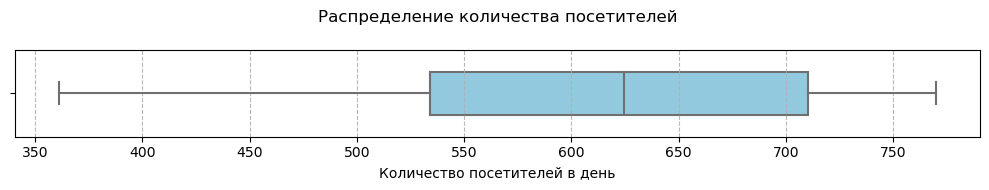

In [13]:
# Создаем фигуру
plt.figure(figsize=(10, 2)) 

# Горизонтальный boxplot
sns.boxplot(data=visitors, x='visitors', orient='h', color='skyblue', width=0.5)
plt.title('Распределение количества посетителей', pad=20)
plt.xlabel('Количество посетителей в день')
plt.grid(axis='x', linestyle='--', alpha=0.9)

plt.tight_layout()
plt.show()

- Все значения находятся в пределах "усов" боксплота.

In [58]:
# Наличие дубликатов 
print(f'Количество дубликатов {visitors.duplicated().sum()}')

Количество дубликатов 0


In [56]:
days_count = (visitors['date'].max().date() - visitors['date'].min().date()).days
print(f"Количество дней: {days_count}")

Количество дней: 30


In [15]:
# Период сбора данных для датасета с посетителями.
print(f"Период сбора данных: {visitors['date'].min().date()} - {visitors['date'].max().date()}")


Период сбора данных: 2019-08-01 - 2019-08-31


In [16]:
# Посмотрим на распределение посетителей по группам
pd.DataFrame(visitors.groupby('group').visitors.sum())

,visitors
group,
A,18736
B,18916


Группы практически идентичны и не требуют коррекции.

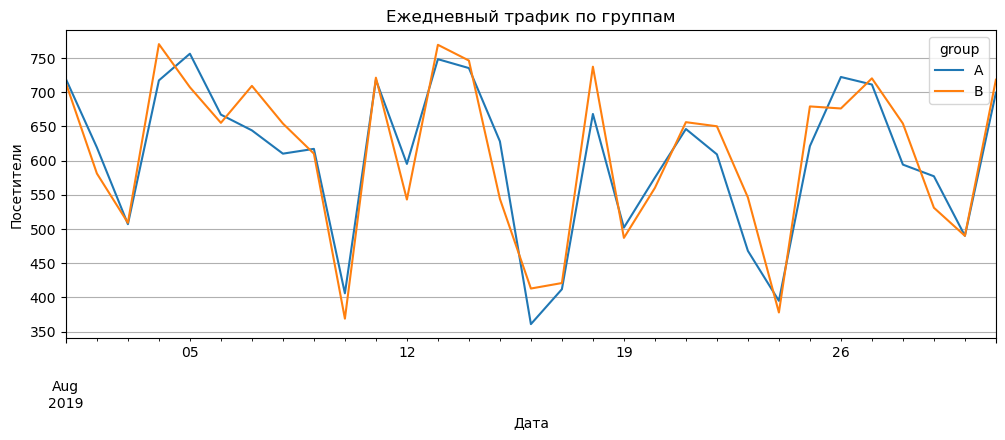

In [17]:
# Распределение траффика по группам.
daily_traffic = visitors.pivot_table(index='date', columns='group', values='visitors', aggfunc='sum')
daily_traffic.plot(figsize=(12, 4))
plt.title('Ежедневный трафик по группам')
plt.ylabel('Посетители')
plt.xlabel('Дата')
plt.grid(True)

plt.show()

<a id='visit' a>

**Итог обработки датасета c посетителями(visiters.csv):**


- Типы данных приведены в соответствие: group → категориальный тип>- date → datetime формат
- В данных нет выборосов , пропусков или дубликатов.
- Данные о посетителях для A/B-теста собирались в течение августа 2019 года, охватывая полный календарный месяц с 1 по 31 августа.
- Изменение траффика для обеих группы подтверждает корректность сплит системы.
- Значительные колебания , скорее всего, обусловлены перепадами активности в разные дни недели.


<a id='buy' a>

### 1.3 Покупки(orders)

In [18]:
display(orders.head())
orders.info()

,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,1650,B
1,2804400009,3642806036,2019-08-15,730,B
2,2961555356,4069496402,2019-08-15,400,A
3,3797467345,1196621759,2019-08-15,9759,B
4,2282983706,2322279887,2019-08-15,2308,B


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   transactionId  1197 non-null   int64 
 1   visitorId      1197 non-null   int64 
 2   date           1197 non-null   object
 3   revenue        1197 non-null   int64 
 4   group          1197 non-null   object
dtypes: int64(3), object(2)
memory usage: 46.9+ KB


In [19]:
# Приведём колонки к нижнему регистру и удалим возможные пробелы.
orders.columns = [x.lower().replace(' ', '') for x in orders.columns]

In [20]:
# Колонку с датой конвертируем в тип datetime.
orders['date'] = pd.to_datetime(orders.date)

In [21]:
print(f"Период сбора данных для покупок:     {orders['date'].min().date()} - {orders['date'].max().date()}")
print(f"Период сбора данных для посетителей: {visitors['date'].min().date()} - {visitors['date'].max().date()}")

Период сбора данных для покупок:     2019-08-01 - 2019-08-31
Период сбора данных для посетителей: 2019-08-01 - 2019-08-31


Данные о покупках соответствуют периоду сбора информации о посетителях и были зафиксированы в течение августа 2019 года.

Text(0.5, 0, 'Стоимость заказа')

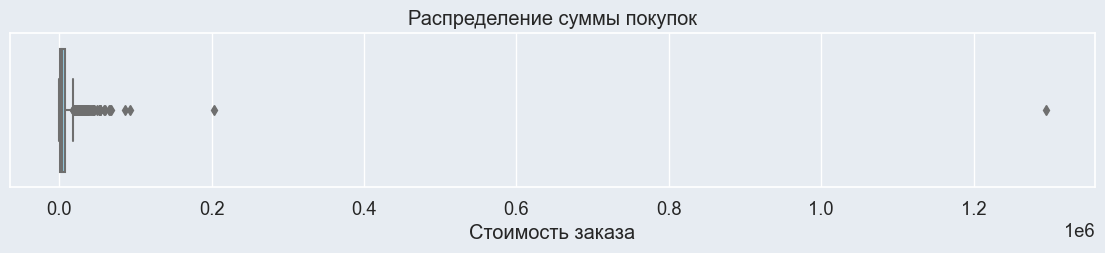

In [82]:
# Посмотрим на выбросы для колонки со стоимостью заказов.
plt.figure(figsize=(14,2))
sns.boxplot(x=orders['revenue'], color='skyblue')
plt.title('Распределение суммы покупок')
plt.xlabel('Стоимость заказа')

In [23]:
# Определим знаение границы верхнего "уса"
upper_whisker = np.percentile(orders['revenue'], 75)*1.5

In [24]:
# Посмотрим на наиболее значимые выбросы в колонке revenue
orders.query('revenue > @upper_whisker').sort_values(by='revenue',ascending=False).head(5)

,transactionid,visitorid,date,revenue,group
425,590470918,1920142716,2019-08-19,1294500,B
1196,3936777065,2108080724,2019-08-15,202740,B
858,192721366,1316129916,2019-08-27,93940,A
1136,666610489,1307669133,2019-08-13,92550,A
744,3668308183,888512513,2019-08-27,86620,B


Есть сильные выбросы, которые неравномерно распределены в группах. При проверке гипотез и подсчёте стат. значимости нужно учесть этот момент, сравнить результаты по сырым и очищенным данным.

Посмотрим есть ли в группах пересекающиеся пользователи.

In [25]:
# Создадим два сета для поиска пересечений
group_a_visitors = set(orders[orders['group'] == 'A']['visitorid'])
group_b_visitors = set(orders[orders['group'] == 'B']['visitorid'])

# Пользователи, которые есть в обеих группах
common_visitors = group_a_visitors & group_b_visitors
print(f' Процент пересекающихся пользователей: {len(common_visitors)/len(orders.visitorid):.2%}')

 Процент пересекающихся пользователей: 4.85%


In [26]:
orders = orders[~orders.visitorid.isin(common_visitors)]

Для обеспечения чистоты эксперимента мы удалим пользователи, присутствовавшие в обеих группах теста. Пересекающиеся пользователи составляли менее 5% от общей выборки, что соответствует допустимому порогу для A/B-тестирования. Данная мера позволяет минимизировать искажение метрик и сохранить статистическую значимость результатов.

In [27]:
orders.groupby('group').visitorid.count()

group
A    468
B    548
Name: visitorid, dtype: int64

<a id='buyers' a>

### Итоги предобработки данных (orders.csv)

**Полнота и корректность данных:**

Типы данных приведены в соответствие:
- group → категориальный тип>- date → datetime формат
- Временные периоды датасетов с покупками и посетителями синхронизированы
- Отсутствуют дубликаты и пропущенные значения
- Требуется дополнительный анализ для понимания природы аномалий (технические ошибки/реальные покупки)
- Итоговый размер выборок составил:
>     Группа A: 468 наблюдений
>     Группа B: 548 наблюдений

**Очистка данных:**

Удалены пересекающиеся пользователи (5% от общего числа):
- Исключено 10% пересекающихся наблюдений, что обеспечит чистоту эксперимента.

Данные готовы для проведения A/B-теста после завершения анализа выбросов.

<a id='prior' a>

##  2. Приоритизация гипотез.

#### Для приоритезации гипотез будем использовать фреймворки ICE и RICE.

**Компоненты фреймворков:**

- Impact (Влияние) — Ожидаемый эффект от внедрения гипотезы (шкала 1-10).
- Confidence (Уверенность) — Вероятность успеха гипотезы (1-10).
- Effort (Усилия) — Ресурсы на реализацию (1-10, где 10 — максимальные затраты).
- Reach — Количество пользователей/событий, затронутых гипотезой за определённый период (шкала 1-10).

In [28]:
hypothesis['ICE'] = round((hypothesis.impact * hypothesis.confidence) / hypothesis.efforts,2)
hypothesis.sort_values('ICE', ascending=False, inplace=True)
hypothesis

,hypothesis,reach,impact,confidence,efforts,ICE
8,"Запустить акцию, дающую скидку на товар в день рождения",1,9,9,5,16.20
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6,13.33
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",10,7,8,5,11.20
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конве...",5,3,8,3,8.00
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средни...",8,3,7,3,7.00
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10,2.00
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",3,2,2,3,1.33
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8,1.12
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1,1.00


In [29]:
hypothesis['RICE'] = (hypothesis.impact * hypothesis.confidence * hypothesis.reach)/hypothesis.efforts
hypothesis.sort_values('RICE', ascending=False, inplace=True)
hypothesis

,hypothesis,reach,impact,confidence,efforts,ICE,RICE
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",10,7,8,5,11.20,112.0
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средни...",8,3,7,3,7.00,56.0
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6,13.33,40.0
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конве...",5,3,8,3,8.00,40.0
8,"Запустить акцию, дающую скидку на товар в день рождения",1,9,9,5,16.20,16.2
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8,1.12,9.0
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10,2.00,4.0
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",3,2,2,3,1.33,4.0
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1,1.00,3.0


Применение фреймворка RICE значительно изменило приоритетность гипотез из-за влияния множителя Reach. В результате:
- **Гипотезы №7** и **№2** были определены как наиболее приоритетные, так как тестируемые нововведения оказывают более глобальное влияние на пользовательский опыт.
- Все три остальных компонента фреймворка (Impact, Confidence, Ease) также демонстрируют высокие значения при относительно низких затратах (знаменатель Efforts).

 

<a id='test' a>

##  3.  A/B-тест

In [30]:
# создаем массив уникальных пар значений дат и групп теста
datesGroups = orders[['date','group']].drop_duplicates()

In [31]:
datesGroups.head(4)

,date,group
0,2019-08-15,B
7,2019-08-15,A
45,2019-08-16,A
47,2019-08-16,B


Выполним агрегацию данных с **заказами** и **посетителями** по дням и группам A/B-теста, создавая кумулятивную (нарастающую) статистику.

In [32]:
ordersAggregated = datesGroups.apply(
    lambda x: orders[np.logical_and(
    orders['date'] <= x['date'],
    orders['group'] == x['group'])]
    .agg({'date' : 'max',
          'group' : 'max',
          'transactionid' : 'nunique',
          'visitorid' : 'nunique',
          'revenue' : 'sum'}),
    axis=1).sort_values(by=['date','group'])
ordersAggregated.head()

,date,group,transactionid,visitorid,revenue
55,2019-08-01,A,23,19,142779
66,2019-08-01,B,17,17,59758
175,2019-08-02,A,42,36,234381
173,2019-08-02,B,40,39,221801
291,2019-08-03,A,66,60,346854


In [33]:
# получаем агрегированные кумулятивные по дням данные о посетителях интернет-магазина 
visitorsAggregated = datesGroups.apply(
    lambda x: visitors[np.logical_and(visitors['date'] <= x['date'], 
    visitors['group'] == x['group'])].
    agg({'date' : 'max', 'group' : 'max', 'visitors' : 'sum'}), 
    axis=1).sort_values(by=['date','group'])

visitorsAggregated.head()

,date,group,visitors
55,2019-08-01,A,719
66,2019-08-01,B,713
175,2019-08-02,A,1338
173,2019-08-02,B,1294
291,2019-08-03,A,1845


In [34]:
# объединим таблиськи
cumulativeData = ordersAggregated.merge(visitorsAggregated,left_on=['date', 'group'],right_on=['date', 'group'])

In [63]:
cumulativeData.head()

,date,group,orders,buyers,revenue,visitors,conversion
0,2019-08-01,A,23,19,142779,719,0.031989
1,2019-08-01,B,17,17,59758,713,0.023843
2,2019-08-02,A,42,36,234381,1338,0.031390
3,2019-08-02,B,40,39,221801,1294,0.030912
4,2019-08-03,A,66,60,346854,1845,0.035772


In [36]:
# Меняем названия колонок
cumulativeData.columns = ['date', 'group', 'orders', 'buyers', 'revenue', 'visitors']

In [37]:
cumulativeData.head(3)

,date,group,orders,buyers,revenue,visitors
0,2019-08-01,A,23,19,142779,719
1,2019-08-01,B,17,17,59758,713
2,2019-08-02,A,42,36,234381,1338


In [38]:
# Отдельные переменные для каждой группы.
cumulativeRevenueA = cumulativeData[cumulativeData['group']=='A'][['date','revenue', 'orders']]
cumulativeRevenueB = cumulativeData[cumulativeData['group']=='B'][['date','revenue', 'orders']]

### 3.1 График кумулятивной выручки по группам.

<a id='gr1' a>

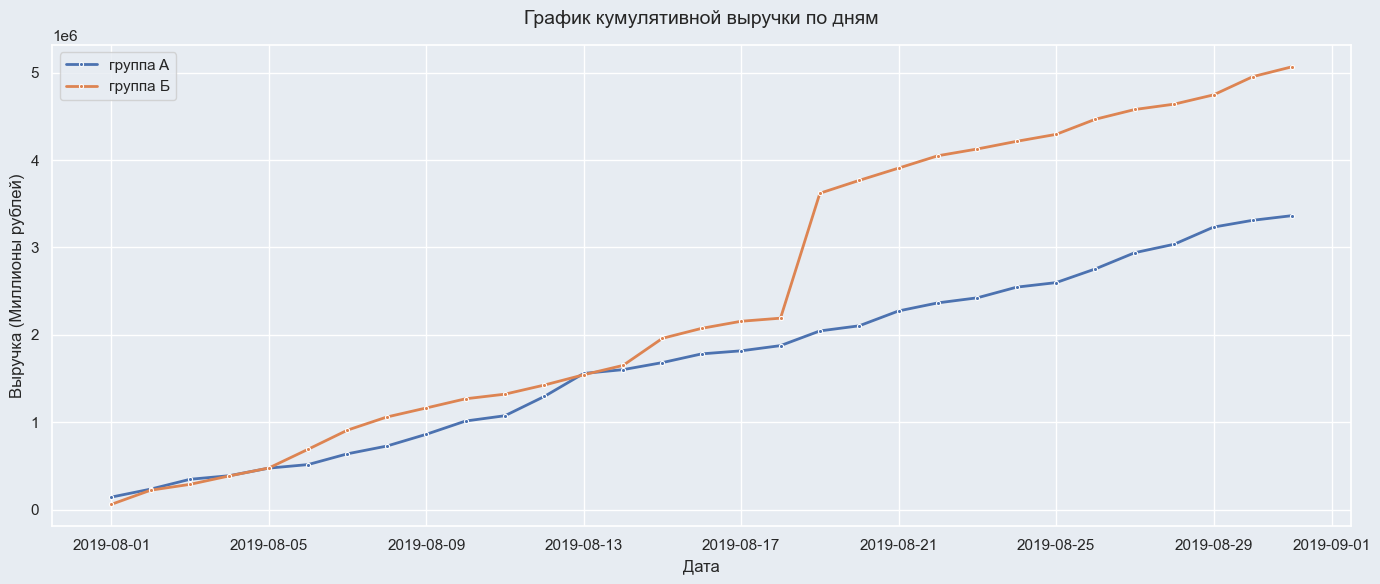

In [39]:
sns.set(
    rc={'axes.facecolor':'#e7ecf2',
        'figure.facecolor':'#e7ecf2'},
        font_scale= 1)

plt.figure(figsize=(14,6))

sns.lineplot(data=cumulativeRevenueA, x='date', y="revenue", label='группа A',marker ='.', linewidth=2)
sns.lineplot(data=cumulativeRevenueB, x='date', y="revenue", label='группа Б',marker ='.', linewidth=2)

plt.ylabel('Выручка (Миллионы рублей)')
plt.title('График кумулятивной выручки по дням',pad=15,size=14)
plt.legend()
plt.xlabel(f'Дата')
plt.tight_layout()


Аномальный скачок прибыли в группе Б. Это те самые выбросы, о которых мы говорил.

<a id='check' a>

### 3.2 График среднего чека по группам.

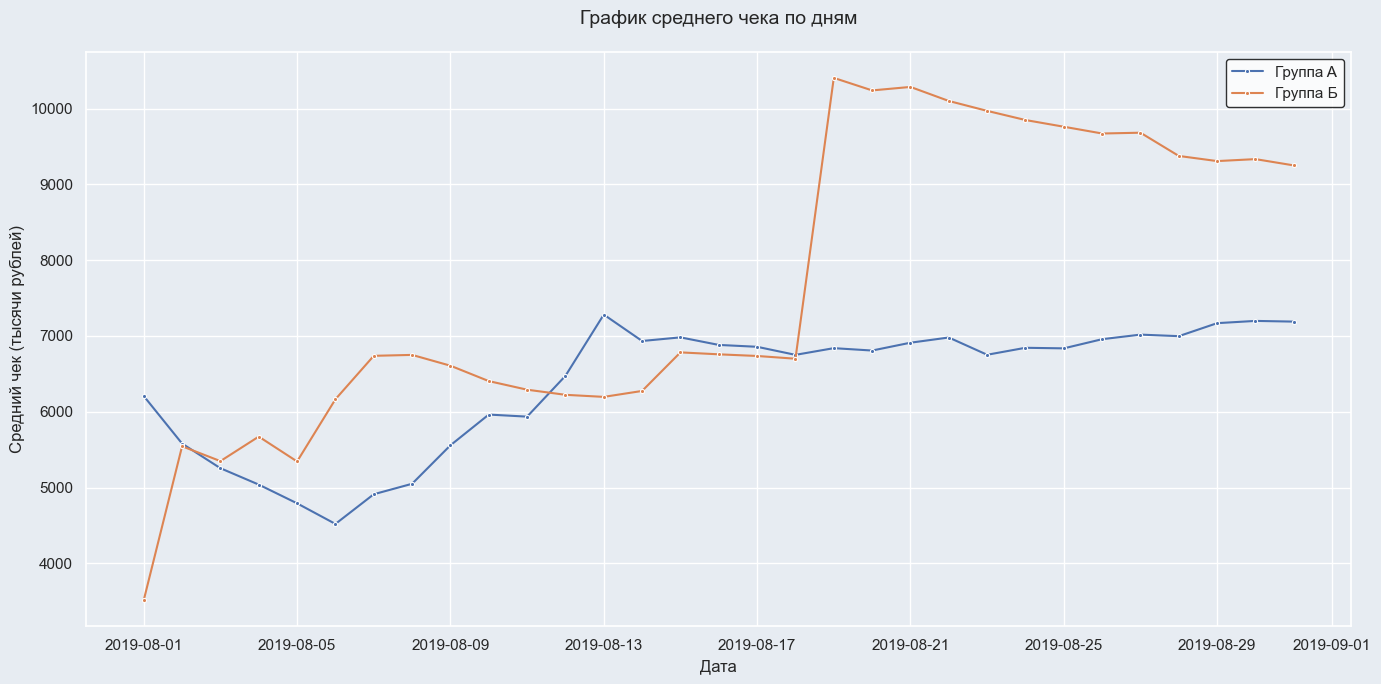

In [40]:
# Делаем фигуру
plt.figure(figsize=(14,7))
sns.lineplot(data=cumulativeRevenueA, 
             x='date',
             y=cumulativeRevenueA['revenue']/cumulativeRevenueA['orders'],
             label='Группа A',
             marker='.')

sns.lineplot(data=cumulativeRevenueB,
             x='date',
             y=cumulativeRevenueB['revenue']/cumulativeRevenueB['orders'],
             label='Группа Б',
             marker='.')

plt.title('График среднего чека по дням',size=14, pad=20)
plt.xlabel('Дата')
plt.ylabel('Cредний чек (тысячи рублей)')
plt.legend(
    frameon=True,          
    facecolor='white',     
    edgecolor='black'
    
)
plt.tight_layout()
plt.show()

В группе **"Б"** виден резкий скачок из за крупного заказа, в середине периода наблюдений. Тем не менее, разрыв средних значений чека остаётся заметным даже после нормализаци.

<a id='check2' a>

### 3.3 График относительного изменения кумулятиного среднего чека группы B к группе A.

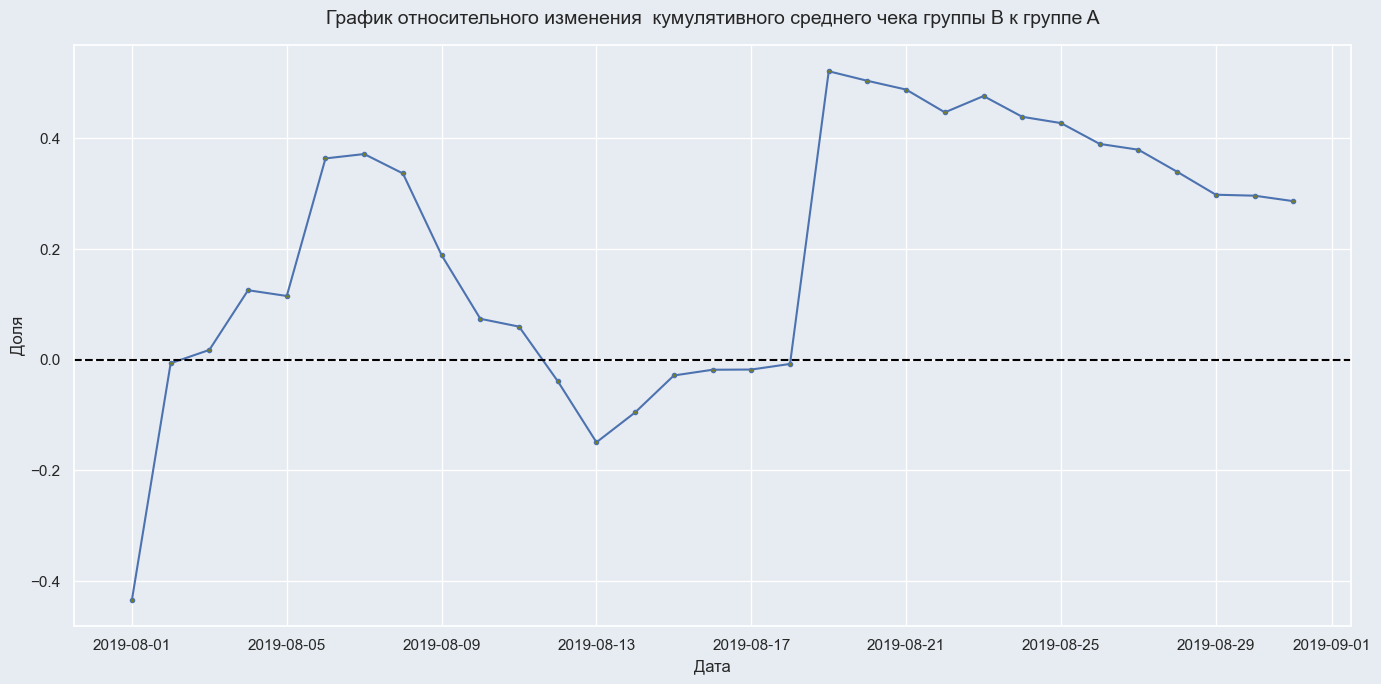

In [41]:
# Создаём фигуру
plt.figure(figsize=(14,7))

# Объединяем данные заказов и выручки групп А и Б
mergedCumulativeRevenue = cumulativeRevenueA.merge(cumulativeRevenueB, 
                                                  left_on='date',
                                                   right_on='date',
                                                   how='left',
                                                   suffixes=['A', 'B'])

# Получаем средний чек по дням для каждой группы и соотносим друг с другом
(plt.plot(mergedCumulativeRevenue['date'],
          (mergedCumulativeRevenue['revenueB']/mergedCumulativeRevenue['ordersB'])
          /(mergedCumulativeRevenue['revenueA']/mergedCumulativeRevenue['ordersA'])-1,
          marker='.',markerfacecolor='olive'))

plt.axhline(y=0, color='black', linestyle='--')
plt.title('График относительного изменения  кумулятивного среднего чека группы B к группе A', size=14, pad=15)
plt.xlabel('Дата')
plt.ylabel('Доля')
plt.tight_layout()
plt.show()

График различия сильно скачет из за крупных заказов. Относительная разница составляет около 27 процентов к концу наблюдений в пользу группы Б.

<a id='graph4' a>

### 3.4 График кумулятивной конверсии по группам A/B теста

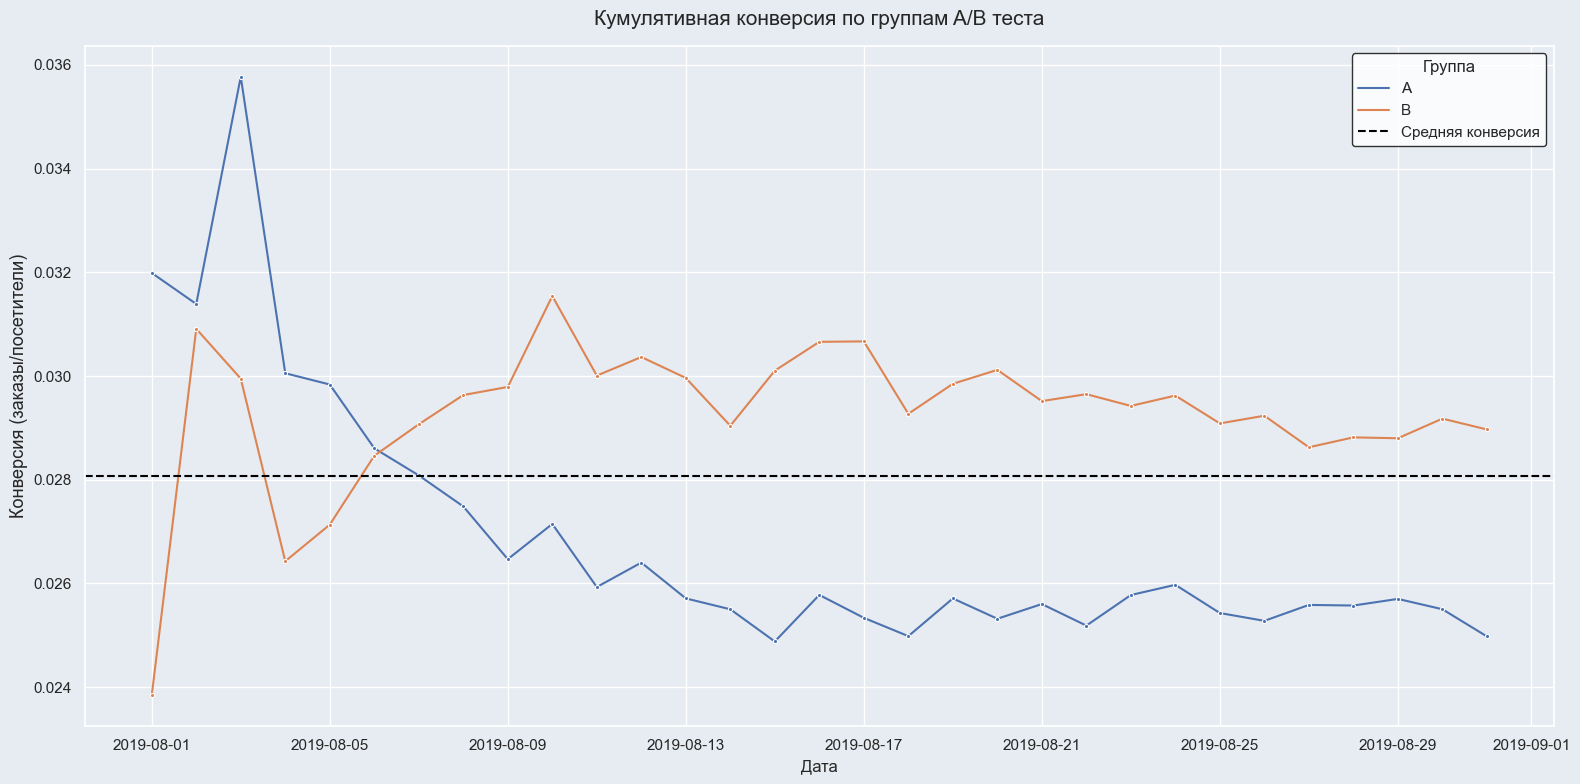

In [42]:
# добавим переменную с конверсией посетителей в покупателей
cumulativeData['conversion'] = cumulativeData['orders'] / cumulativeData['visitors']

# Строим фигуру
plt.figure(figsize=(16, 8))

# Добавляем график
sns.lineplot(data=cumulativeData, 
             x='date', 
             y='conversion', 
             hue='group',
             linewidth=1.5,
             marker='.')

# Настройки оформления
plt.title('Кумулятивная конверсия по группам A/B теста', size=15, pad=15)
plt.xlabel('Дата')
plt.ylabel('Конверсия (заказы/посетители)', size=13)

# Добавляем линию среднего
plt.axhline(y=cumulativeData['conversion'].mean(), 
            color='black', 
            linestyle='--',
            label='Средняя конверсия')
plt.legend(
    frameon=True,          
    facecolor='white',     
    edgecolor='black',
    title='Группа'
)

plt.tight_layout()
plt.show()

**Группа Б в лидерах.** К концу наблюдений разница конверсий составила ~0.04%.

<a id='graph5' a>

### 3.5  График относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A

In [43]:
# Создадим переменную соотношения конверский по дням для двух групп
cumulative_conv = (cumulativeData.query('group == "B"')
                  .conversion.reset_index(drop=True) / cumulativeData.query('group == "A"')
                  .conversion.reset_index(drop=True)-1)

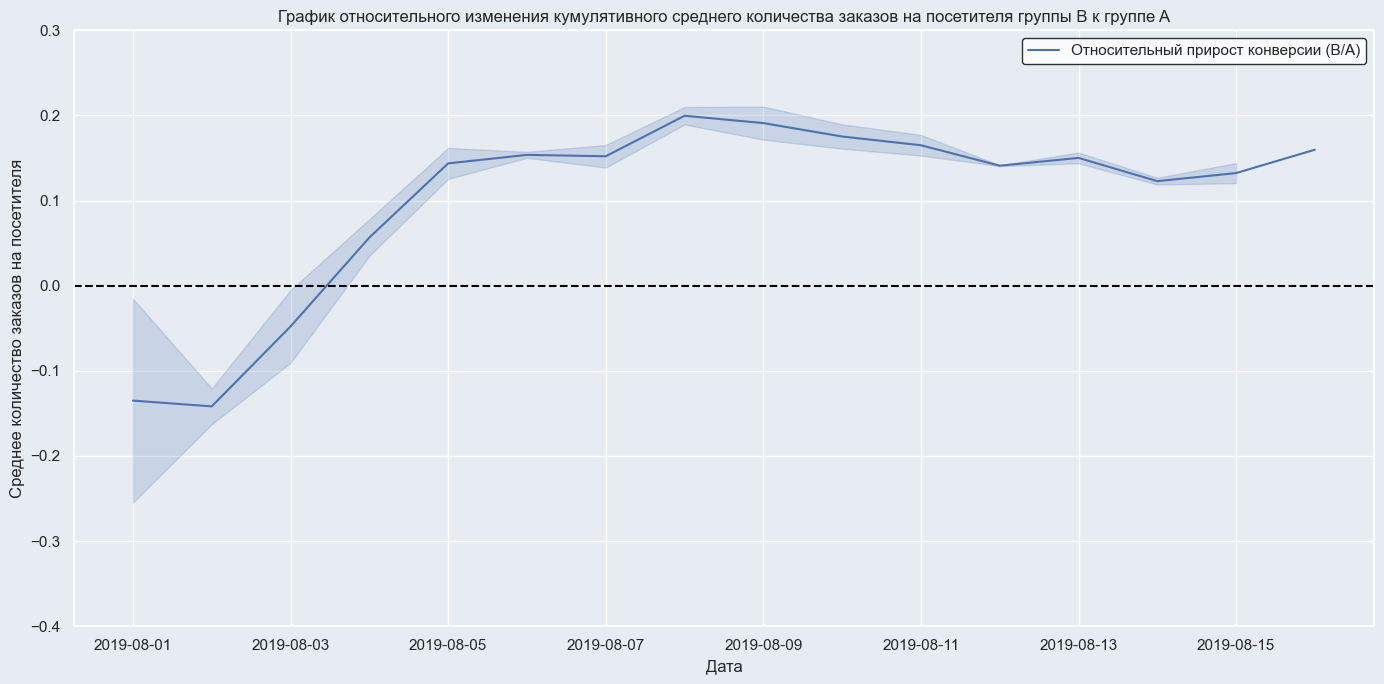

In [44]:
# Фигура
plt.figure(figsize=(14, 7))

# График соотношения конверсий группы Б к А.
sns.lineplot(data=cumulativeData, x='date',y= cumulative_conv
         , label="Относительный прирост конверсии (B/A)")

# Добавляем линию среднего.
plt.axhline(y=0, color='black', linestyle='--')

# Настройки оформления
plt.title('График относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A')
plt.xlabel('Дата')
plt.ylabel('Среднее количество заказов на посетителя')
plt.legend(
    frameon=True,          
    facecolor='white',     
    edgecolor='black'      
)
plt.ylim(-0.4, 0.3)
plt.tight_layout()
plt.grid(True)

- График показывает, что группа B выходит вперед после 6-го дня теста и останавилвается на 15% разнице к концу наблюдений.
- В последней трети эксперимента результаты стабилизируются.

<a id='point' a>

### 3.6 Точечный график количества заказов по пользователям.

In [45]:
# Переменная для точечного графика с количеством заказов на каждого уникального пользователя.
orders_for_scatter = orders.pivot_table(index='visitorid'
                                        ,values='transactionid',
                                        aggfunc='nunique').reset_index()

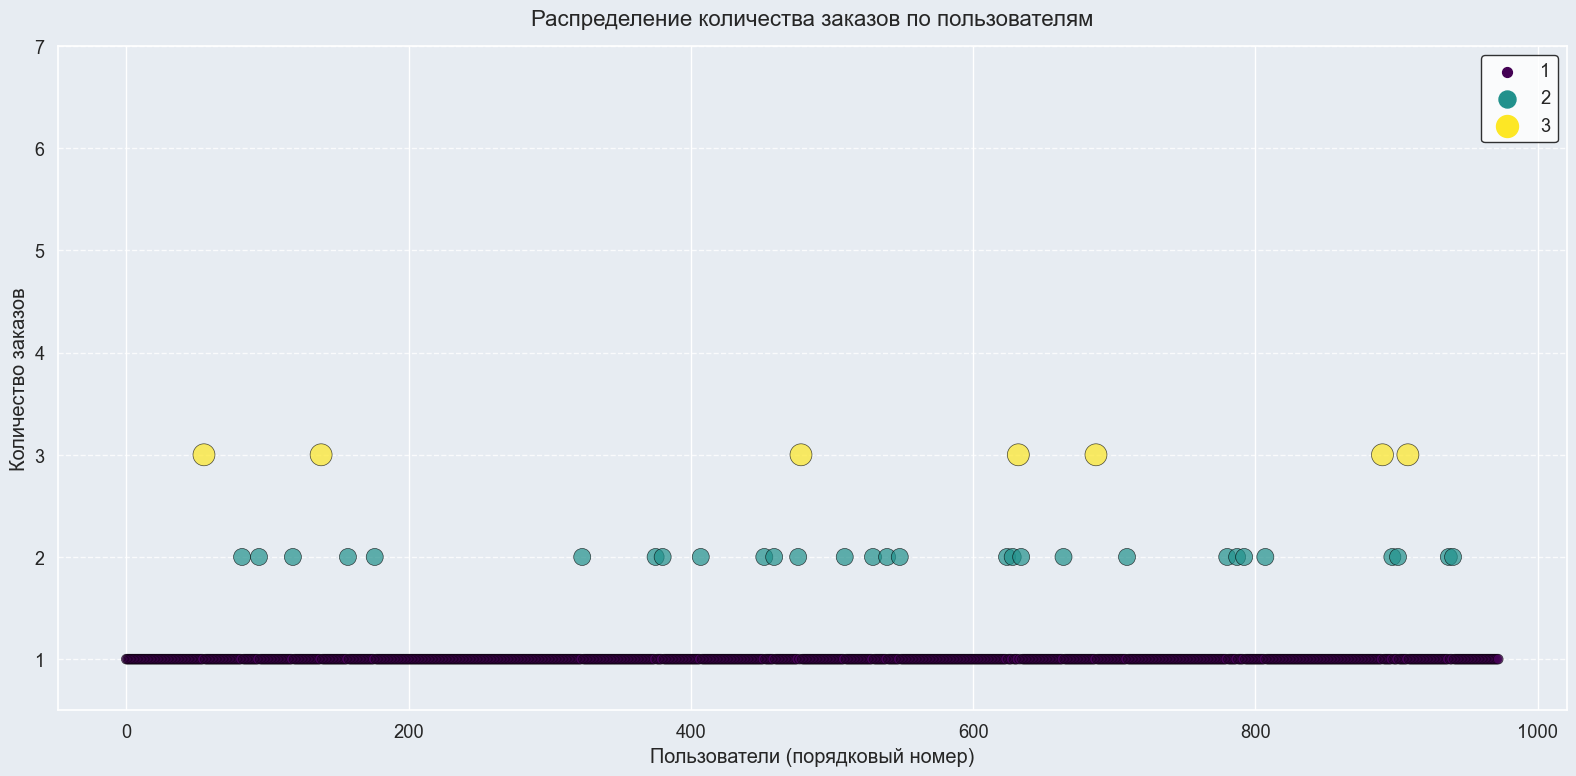

In [46]:
plt.figure(figsize=(16, 8), dpi=100)

sns.set(
    rc={'axes.facecolor':'#e7ecf2',
        'figure.facecolor':'#e7ecf2'},
        font_scale= 1.2)

#  scatterplot для количества заказов на уникального пользователя
ax = sns.scatterplot(
    data=orders_for_scatter,
    x=range(len(orders_for_scatter)),
    y="transactionid",
    hue="transactionid",  
    palette="viridis",    
    size="transactionid",
    sizes=(50, 250),      
    alpha=0.7,           
    edgecolor='black',    
    linewidth=0.5,
)

# Настройка осей и оформления
ax.set(
    xlabel='Пользователи (порядковый номер)',
    ylabel='Количество заказов',
    
    ylim=(0.5, 7)
)
ax.set_title('Распределение количества заказов по пользователям', fontsize=16,pad=15) 

# Горизонтальные линии для удобства чтения
ax.yaxis.grid(True, linestyle='--', alpha=0.8)
ax.set_yticks(range(1,8))
ax.set_yticklabels(range(1,8), fontsize=13)

plt.legend(
    frameon=True,          
    facecolor='white',     
    edgecolor='black'      
)

plt.tight_layout()


In [81]:
(
    orders_for_scatter.transactionid.value_counts()
                  .reset_index()
                  .rename(columns={'index':'Сделано заказов','transactionid':'Покупатели'}))

,Сделано заказов,Покупатели
0,1,937
1,2,29
2,3,7


In [70]:
# Посчитает количество заказов которые входят в 96-ю и 99-ю перцентиль.
np.percentile(orders_for_scatter.transactionid,[96,99])

array([1., 2.])

**Распределение заказов:**

- Подавляющее большинство пользователей (~96%) совершили только один заказ.
- Только 29 покупателей (~3%) сделали повторный заказ (второй раз).
- Лишь 7 (менее 1%) пользователей заказали в третий раз.

Из-за большого числа разовых заказов точки на графике сливаются в сплошную линию.
Замечу отсутсвие  явных выбросов или аномальных значений в количестве заказов на одного пользователя.

**Вывод:**
Повторные покупки редки — лишь небольшая доля пользователей (менее 5%) совершает второй и третий заказы

<a id='point2' a>

### 3.7 Точечный график стоимости заказов по пользователям.

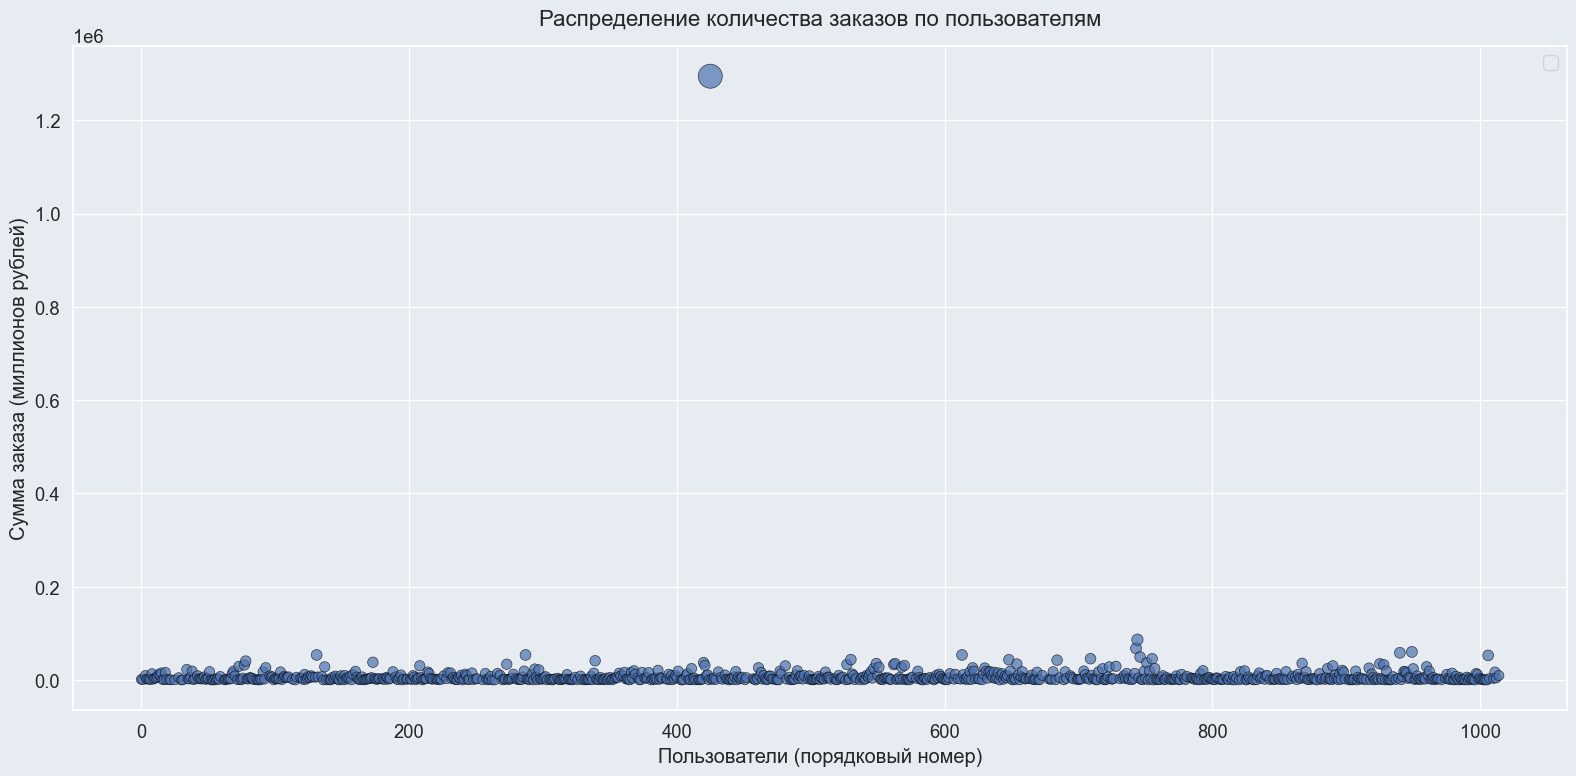

In [49]:
plt.figure(figsize=(16, 8), dpi=100)

sns.set(
    rc={'axes.facecolor':'#e7ecf2',
        'figure.facecolor':'#e7ecf2'},
        font_scale= 1.2)

#  scatterplot для количества заказов на уникального пользователя
ax = sns.scatterplot(
    data=orders,
    x=pd.Series(range(0, len(orders))),
    y="revenue",    
    size="revenue",
    sizes=(50, 300),      
    alpha=0.7,           
    edgecolor='black',    
    linewidth=0.5,
)

# Настройка осей и оформления
ax.set(
    xlabel='Пользователи (порядковый номер)',
    ylabel='Сумма заказа (миллионов рублей)',
    )
ax.set_title('Распределение стоимости заказов по пользователям', fontsize=16, pad=15) 

plt.legend('' 
)

plt.tight_layout()

In [50]:
# Сохраним значения 95-го и 99-го перцентилей для последующей фильтрации данных при тестировании гипотез
rev_95 = np.percentile(orders['revenue'] , 95)
rev_99 = np.percentile(orders['revenue'] , 99)

In [51]:
print(np.percentile(orders['revenue'] , [95, 99]))

[26785. 53904.]


- 99% процентов всех заказов не дороже ~50 тысяч рублей.
- Лишь один заказаз составил более миллиона рублей. Его природу стоит установить , так как есть вероятность закравшейся тех. ошибки.


<a id='4' a>

### 4 Формулировка, проверка и интерпретация статистических гипотез.

#### 4.1 Проверка гипотезы о различиях в среднем количестве заказов на пользователя в двух группах (критерий Манна-Уитни)

**Создание переменных:**

**ordersByUsersA** и **ordersByUsersB** – таблицы со столбцами ['userId', 'orders'], где:
- userId – уникальный идентификатор пользователя
- orders – количество заказов для каждого пользователя (только те, кто совершил ≥1 заказ).

**Подготовка выборок для теста:**

**sampleA** и **sampleB** – массивы, где:
- Пользователям с заказами соответствует их фактическое количество заказов.
- Пользователям без заказов присваивается значение 0.

<a id='crit' a>

**Выбор статистического критерия:**

Учитывая негауссовское распределение данных (преобладание нулей и единичных заказов), используем непараметрический U-критерий Манна-Уитни:
- Критерий подходит для сравнения двух независимых выборок с произвольными распределениями.
- Устойчив к несбалансированным размерам выборок.

**Гипотезы**

- H0: Среднее количество заказов на посетителя групп A и B равны, статистически значимых отличий нет;

- H1: Среднем количество заказов на посетителя групп A и B различны, статистически значимые отличия есть.

In [78]:
# Создаём таблицы с заказами для каждого участника группы.
ordersByUsersA = (
    orders[orders['group'] == 'A']
    .groupby('visitorid', as_index=False)
    .agg({'transactionid': pd.Series.nunique})
)
ordersByUsersA.columns = ['visitorid', 'transactionid']

ordersByUsersB = (
    orders[orders['group'] == 'B']
    .groupby('visitorid', as_index=False)
    .agg({'transactionid': pd.Series.nunique})
)
ordersByUsersB.columns = ['visitorid', 'transactionid'] 

In [76]:
sampleA = pd.concat([
    ordersByUsersA['transactionid'],  # фактические заказы
    pd.Series(0,  # нули для пользователей без заказов
              index=np.arange(
                  visitors.query('group == "A"').visitors.sum() - len(ordersByUsersA['transactionid'])
              ),
              name='orders')
], axis=0)

# Аналогично для группы B
sampleB = pd.concat([
    ordersByUsersB['transactionid'],
    pd.Series(0,
              index=np.arange(
                  visitors.query('group == "B"').visitors.sum() - len(ordersByUsersB['transactionid'])
              ),
              name='orders')
], axis=0)

# Проводим U-тест Манна-Уитни
p_value = stats.mannwhitneyu(sampleA, sampleB)[1]
print(f'P-value: {p_value:.3f}')

# Считаем относительную разницу средних
relative_diff = sampleB.mean() / sampleA.mean() - 1
print(f'Различия в группах: {relative_diff:.1%}')

P-value: 0.011
Различия в группах: 16.0%


- Отвергаем нулевую гипотезу. 
- Группа B показала увеличение среднего числа заказов на 16% по сравнению с группой A.

<a id='5' a>

### 2.11 Сравнение среднего чека между группами по необработанным данным (критерий Манна-Уитни)

Создадим два массива со стоимостью заказов для каждого покупателя в двух группах. Для сравнения групп будем использовать критерий Манна-Уитни.

**Гипотезы:**

- H0: Средние чеки групп A и B равны, статистически значимых отличий нет;

- H1: Средние чеки групп A и B различны, статистически значимые отличия есть.

In [54]:
# Выделяем данные по группам
group_a_revenue = orders[orders['group'] == 'A']['revenue']
group_b_revenue = orders[orders['group'] == 'B']['revenue']

# Проводим статистический тест
mwu_test_result = stats.mannwhitneyu(group_a_revenue, group_b_revenue)
p_value = mwu_test_result.pvalue

# Рассчитываем разницу в средних
revenue_ratio = group_b_revenue.mean() / group_a_revenue.mean()
relative_difference = revenue_ratio - 1


print(f'P-value: {p_value:.3f}')
print(f'Различия в группах: {relative_difference:.2%}')

P-value: 0.829
Различия в группах: 28.66%


- Относительные различия составляют ~ 29 процентов, но p_value выше значения стат. значимости.
- Принимаем нулевую гипотезу.

<a id='clean' a>

### 2.11 Сравнение среднего чека между группами по очищенным данным (критерий Манна-Уитни).

Отфильтруем 1% самых дорогих заказов, используя ранее объявленный 99-й перцентиль.

In [55]:
# Выделяем данные по группам с фильтрами по стоимости заказа.
group_a_revenue = orders[(orders['group'] == 'A') & (orders.revenue < rev_99)]['revenue']
group_b_revenue = orders[(orders['group'] == 'B') & (orders.revenue < rev_99)]['revenue']

# Проводим статистический тест
mwu_test_result = stats.mannwhitneyu(group_a_revenue, group_b_revenue)
p_value = mwu_test_result.pvalue

# Рассчитываем разницу в средних
revenue_ratio = group_b_revenue.mean() / group_a_revenue.mean()
relative_difference = revenue_ratio - 1


print(f'P-value: {p_value:.3f}')
print(f'Различия в группах: {relative_difference:.2%}')

P-value: 0.954
Различия в группах: -1.39%


- Средние значения в группах отличаются лишь на 1.39%
- Нулевая гипотеза (H₀) не отвергается – различия между группами не являются статистически значимыми.

<a id='last' a>
    

### Вывод по приоритезации гипотез:

После применения фреймворка RICE наиболее приоритетными гипотезами стали:

1. Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок. **(112 баллов)**
2. Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа. **(56 баллов)**
3. Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей. **(40 баллов)**

### Вывод по результатам A/B-теста

**Основные результаты:**

- Статистически значимые различия обнаружены в среднем количестве заказов – группа Б показала лучший результат.
- Разница в количестве заказов составила 14% в пользу группы Б, что при сохранении среднего чека прямо ведёт к росту выручки.
- Нет значимых различий в среднем чеке (ни по сырым, ни по очищенным данным). 
- Графики метрик стабилизировались к концу теста, что подтверждает достоверность результатов.

Поскольку ключевая метрика (количество заказов) показала значимый прирост, тест можно остановить, зафиксировать победу группы Б и признать успешным.
Стоит отметить, что разница в размерах выборок между группами составила 16%, что превышает рекомендуемый дисбаланс (1%). Это могло повлиять на точность теста, однако основной эффект (рост заказов) статистически подтверждён.

**Бизнес-вывод:**

Внедрение изменений группы Б приведёт к увеличению числа заказов без снижения среднего чека, что позволит нарастить выручку.
Рекомендуется запуск изменений в продакшен с последующим мониторингом ключевых метрик.


**Итог:**

A/B-тест успешно завершён. Группа Б демонстрирует значимое улучшение по количеству заказов при сохранении среднего чека, что делает её предпочтительной для масштабирования.

[В начало](#start)